In [1]:

# imports
import os
import sys
import types
import json

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = fig_dpi
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  pio.renderers.default = "notebook_connected"
except Exception:
  pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass



# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
if r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab2-Propagation_of_Uncertainty_I':
  os.chdir(r'/Users/legoses/Library/CloudStorage/GoogleDrive-nelsonla@byui.edu/My Drive/Lance/PH150/book/labs/Lab2-Propagation_of_Uncertainty_I')

# reset state
%reset

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v
  
  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define


/var/folders/l7/qksjftz12pz0s32y0l3jd4k4cyyb65/T/ipykernel_93352/1675095817.py:20: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats(fig_format)


{"/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/_bootstrap_external.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/zipimport.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/codecs.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/aliases.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/__init__.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.framework/Versions/3.11/lib/python3.11/encodings/utf_8.py": 1696254354.0, "/opt/homebrew/Cellar/python@3.11/3.11.6/Frameworks/Python.

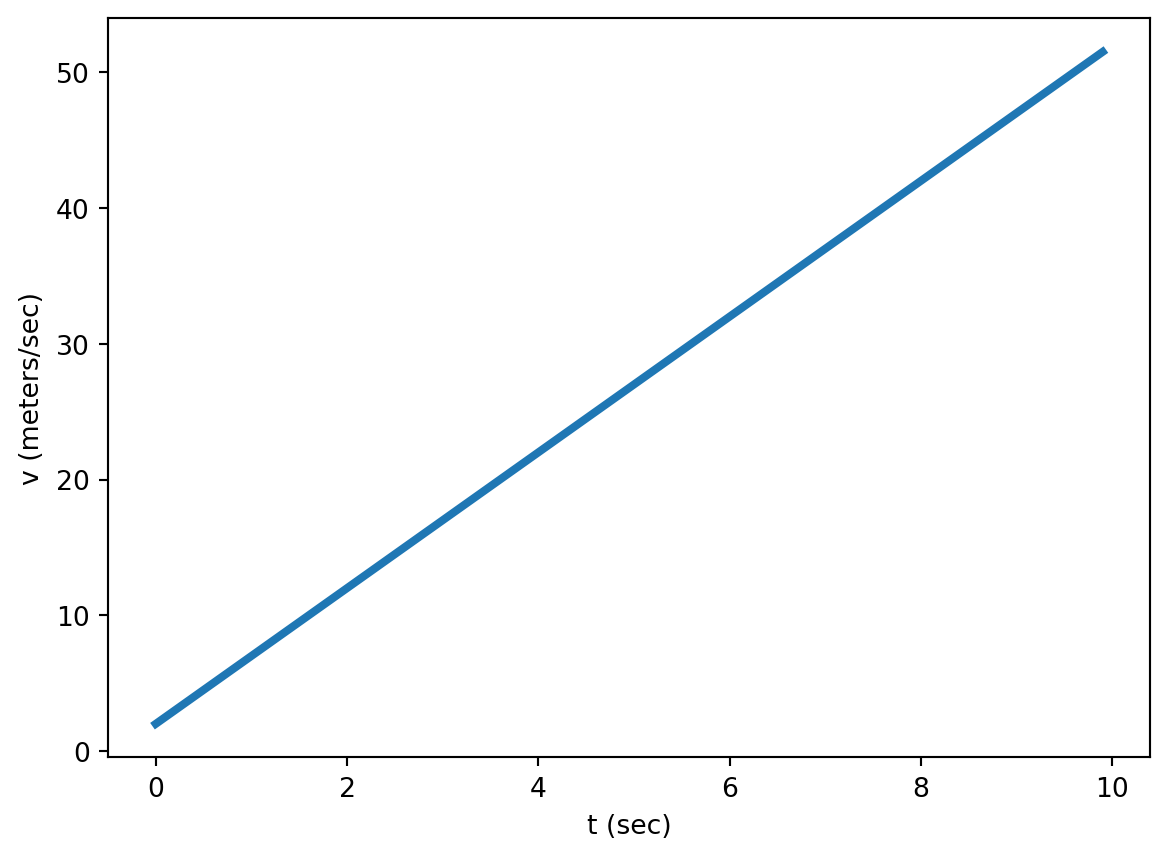

In [2]:
#| eval: true
#| echo: false
#| output: true

from matplotlib import pyplot as plt
from numpy import arange
t = arange(0,10,0.1)
v = 5 * t + 2

plt.plot(t,v,lw = 3)
plt.xlabel("t (sec)")
plt.ylabel("v (meters/sec)")
plt.show()

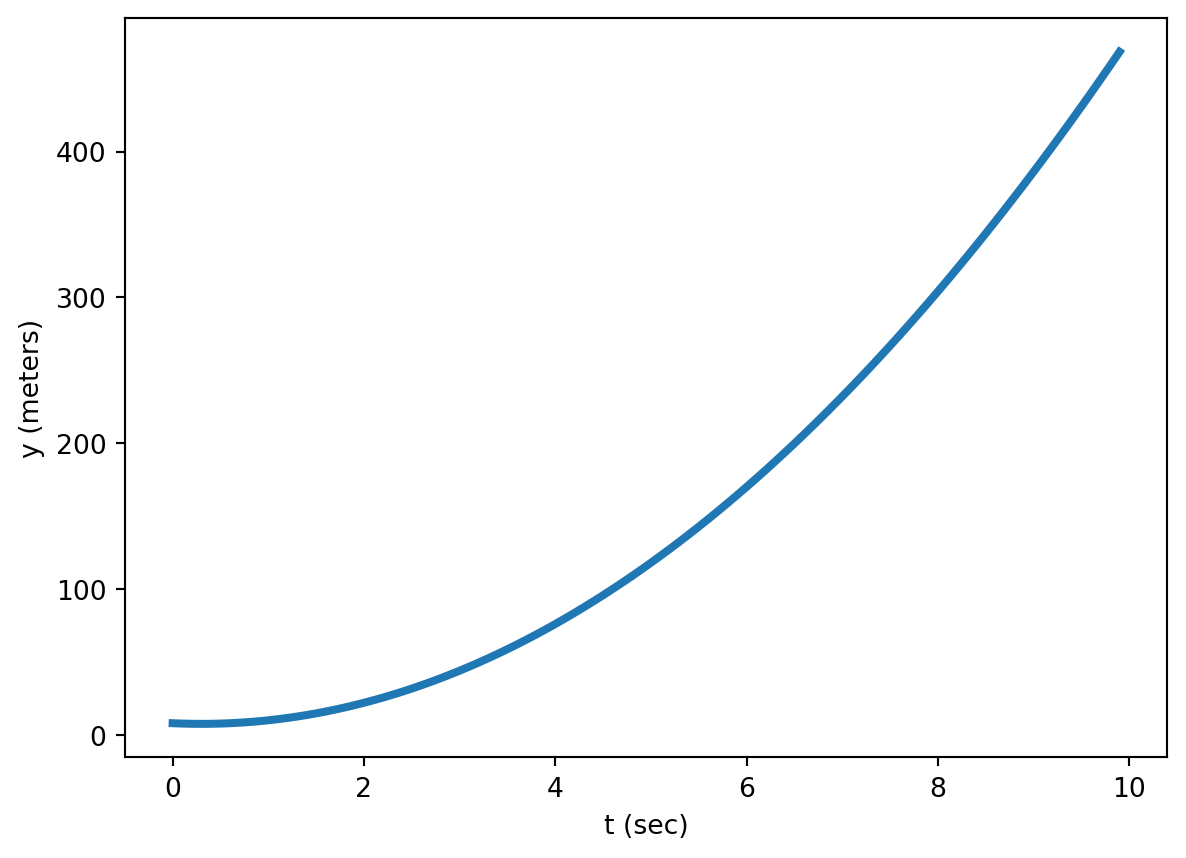

In [3]:
#| eval: true
#| echo: false
#| output: true

from matplotlib import pyplot as plt
from numpy import arange
t = arange(0,10,0.1)
y = 5 * t**2 - 3*t + 8

plt.plot(t,y,lw = 3)
plt.xlabel("t (sec)")
plt.ylabel("y (meters)")
plt.show()

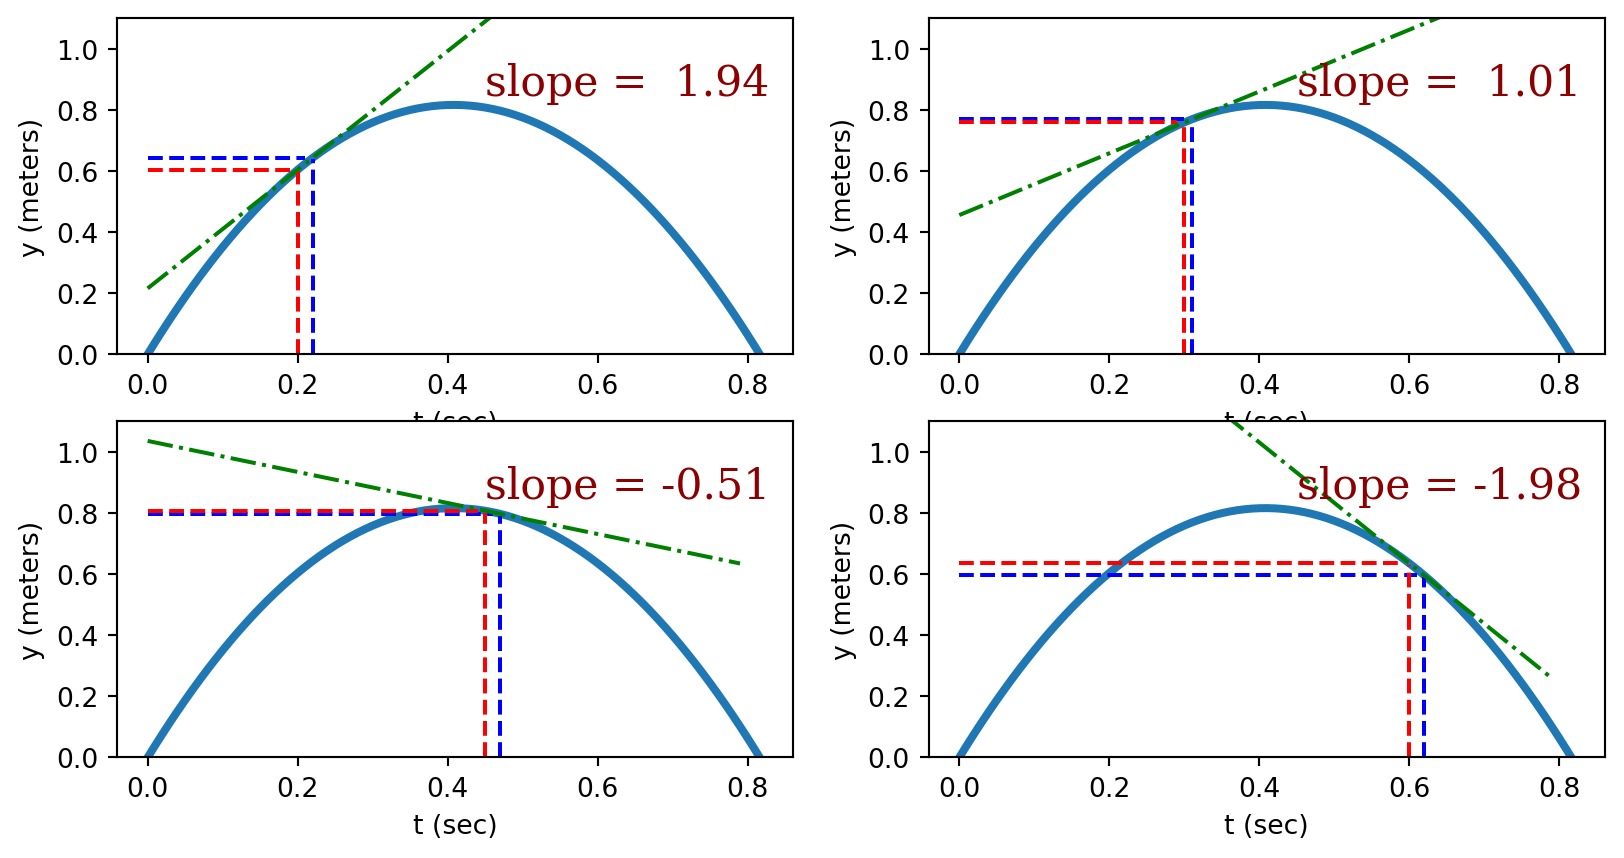

In [4]:
#| eval: true
#| echo: false
#| output: true

from matplotlib import pyplot as plt
from numpy import arange


def f(yi,vi,a,t):
    return yi + vi *t + 1/2 * a * t**2

def slopeTwoPoints(yi,vi,a,ta,tb,axes):
    
    m = (f(yi,vi,a,tb) - f(yi,vi,a,ta)) / (tb - ta) 
    t1 = arange(0,tb,0.01)
    y1 = [yi + vi * tb + 1/2 *a * tb**2 for t in t1]
    axes.plot(t1,y1,'b--')

    y2 = arange(0,yi + vi * tb + 1/2 *a * tb**2,0.01)
    t2 = [tb for t in y2]
    axes.plot(t2,y2,'b--')

    t3 = arange(0,ta,0.01)
    y3 = [yi + vi * ta + 1/2 *a * ta**2 for t in t3]
    axes.plot(t3,y3,'r--')

    y4 = arange(0,yi + vi * ta + 1/2 *a * ta**2,0.01)
    t4 = [ta for t in y4]
    axes.plot(t4,y4,'r--')
    tRange = arange(0,0.8,0.01)
    y = m * tRange + f(yi,vi,a,ta) - ta * m
    axes.plot(tRange,y,'g-.')
    axes.set_ylim(0,1.1)
    font = {'family':'serif','color':'darkred','weight':'normal','size':16}
    axes.text(0.45, 0.85,f"slope = {m:5.2f}",fontdict = font)
    axes.set_xlabel("t (sec)")
    axes.set_ylabel("y (meters)")

a = -9.8
vi = 4
yi = 0
t = arange(0,0.83,0.01)
y = f(yi,vi,a,t)


fig,axs = plt.subplots(2,2,figsize = (10,5))

axs[0,0].plot(t,y,lw = 3)
axs[0,1].plot(t,y,lw = 3)
axs[1,0].plot(t,y,lw = 3)
axs[1,1].plot(t,y,lw = 3)


slopeTwoPoints(yi,vi,a,0.2,0.22,axs[0,0])
slopeTwoPoints(yi,vi,a,0.3,0.31,axs[0,1])
slopeTwoPoints(yi,vi,a,0.45,0.47,axs[1,0])
slopeTwoPoints(yi,vi,a,0.6,0.62,axs[1,1])

plt.show()

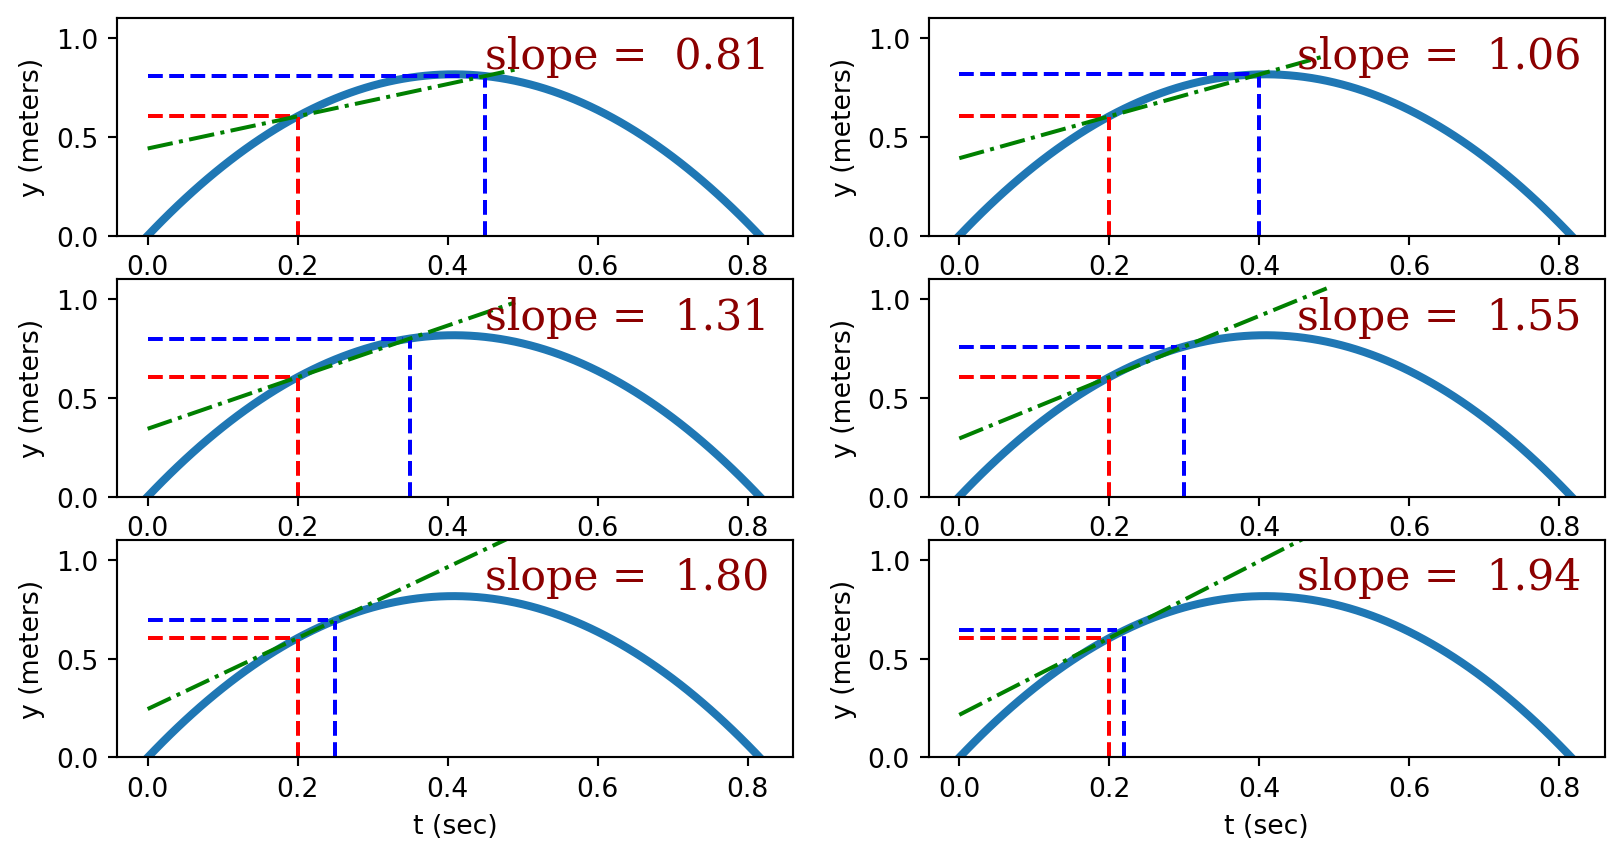

In [5]:
#| eval: true
#| echo: false
#| output: true

from matplotlib import pyplot as plt
from numpy import arange


def f(yi,vi,a,t):
    return yi + vi *t + 1/2 * a * t**2

def slopeTwoPoints(yi,vi,a,ta,tb,axes):
    
    m = (f(yi,vi,a,tb) - f(yi,vi,a,ta)) / (tb - ta) 
    t1 = arange(0,tb,0.01)
    y1 = [yi + vi * tb + 1/2 *a * tb**2 for t in t1]
    axes.plot(t1,y1,'b--')

    y2 = arange(0,yi + vi * tb + 1/2 *a * tb**2,0.01)
    t2 = [tb for t in y2]
    axes.plot(t2,y2,'b--')

    t3 = arange(0,ta,0.01)
    y3 = [yi + vi * ta + 1/2 *a * ta**2 for t in t3]
    axes.plot(t3,y3,'r--')

    y4 = arange(0,yi + vi * ta + 1/2 *a * ta**2,0.01)
    t4 = [ta for t in y4]
    axes.plot(t4,y4,'r--')
    tRange = arange(0,0.5,0.01)
    y = m * tRange + f(yi,vi,a,ta) - ta * m
    axes.plot(tRange,y,'g-.')
    axes.set_ylim(0,1.1)
    font = {'family':'serif','color':'darkred','weight':'normal','size':16}
    axes.text(0.45, 0.85,f"slope = {m:5.2f}",fontdict = font)
    axes.set_xlabel("t (sec)")
    axes.set_ylabel("y (meters)")

a = -9.8
vi = 4
yi = 0
t = arange(0,0.83,0.01)
y = f(yi,vi,a,t)


fig,axs = plt.subplots(3,2,figsize = (10,5))

axs[0,0].plot(t,y,lw = 3)
axs[0,1].plot(t,y,lw = 3)
axs[1,0].plot(t,y,lw = 3)
axs[1,1].plot(t,y,lw = 3)
axs[2,0].plot(t,y,lw = 3)
axs[2,1].plot(t,y,lw = 3)

tb = 0.40
ta = 0.25

#m = 
slopeTwoPoints(yi,vi,a,0.2,0.45,axs[0,0])
slopeTwoPoints(yi,vi,a,0.2,0.4,axs[0,1])
slopeTwoPoints(yi,vi,a,0.2,0.35,axs[1,0])
slopeTwoPoints(yi,vi,a,0.2,0.3,axs[1,1])
slopeTwoPoints(yi,vi,a,0.2,0.25,axs[2,0])
slopeTwoPoints(yi,vi,a,0.2,0.22,axs[2,1])

plt.show()

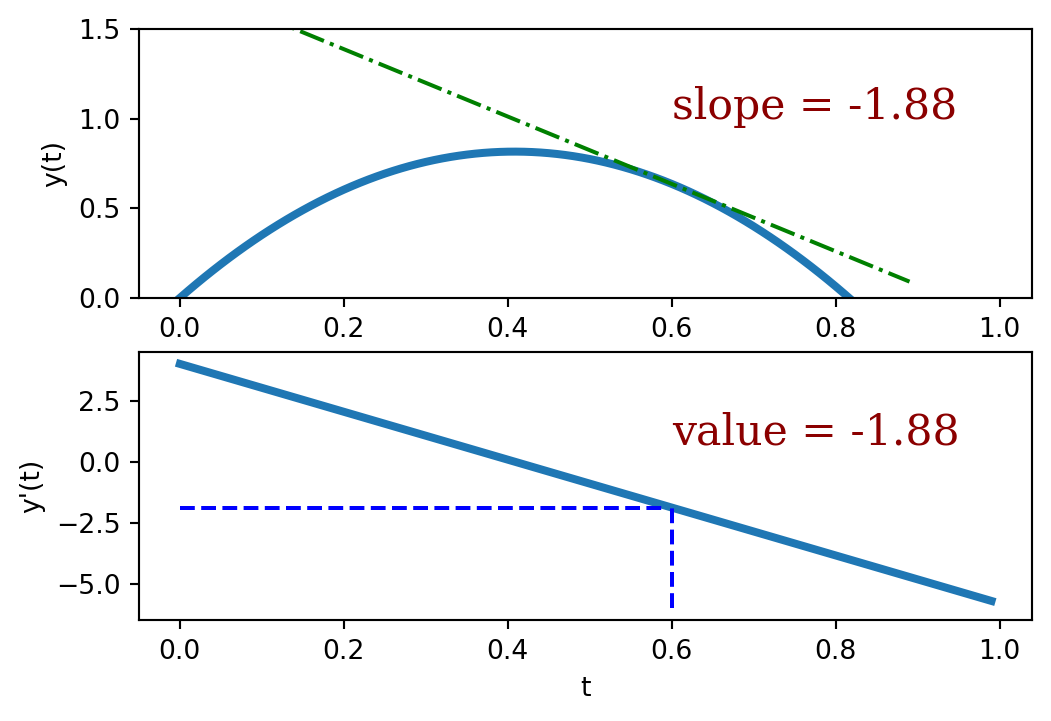

In [6]:
#| eval: true
#| echo: false
#| output: true



from matplotlib import pyplot as plt
from numpy import arange


def f(t):
    return 4 * t - 4.9 * t**2

def slopeTwoPoints(ta,tb,axes):
    
    m = (f(tb) - f(ta)) / (tb - ta) 

#    y2 = arange(-9.8 * ta + 4,0.01)
#    t2 = [ta for x in y2]
#    axes.plot(t2,y2,'b--')

    tRange = arange(0,0.9,0.01)
    y = m * tRange + f(ta) - ta * m
    axes.plot(tRange,y,'g-.')
    axes.set_ylim(0,1.5)
    font = {'family':'serif','color':'darkred','weight':'normal','size':16}
    axes.text(0.6, 1,f"slope = {m:5.2f}",fontdict = font)
    axes.set_xlabel("t")
    axes.set_ylabel("y(t)")

def lines(t,axes):

    t1 = arange(0,t,0.01)
    y1 = [-9.8 * t + 4 for x in t1]
    axes.plot(t1,y1,'b--')

    y2 = arange(-6,-9.8 * t + 4,0.01)
    t2 = [t for x in y2]
    axes.plot(t2,y2,'b--')
    font = {'family':'serif','color':'darkred','weight':'normal','size':16}
    axes.text(0.6, 0.7,f"value = {-9.8 * t + 4:5.2f}",fontdict = font)
    axes.set_xlabel("t")
    axes.set_ylabel("y'(t)")

t = arange(0,1,0.01)
y = f(t)
y2 = 4 - 9.8 * t


fig,axs = plt.subplots(2,1,figsize = (6,4))

axs[0].plot(t,y,lw = 3)
axs[1].plot(t,y2,lw = 3)


slopeTwoPoints(0.6,0.60005,axs[0])
lines(0.6,axs[1])
plt.show()

In [7]:
#| echo: false
#| eval: true

m = 345
l = 5.2
w = 8.4
h = 10.8 

rho = m/l/w/h
print(f"= {rho:5.2f} g/cm^3")

=  0.73 g/cm^3


In [8]:
#| echo: true
#| eval: true

from numpy import sqrt
m = 345
dm = 5
l = 5.2
dl = 0.1
w = 8.4
dw = 0.3
h = 10.8
dh = 0.4 

rho = m/l/w/h
drdl = -m/l**2/w/h
drdw = -m/l/w**2/h
drdh = -m/l/w/h**2
drdm = 1/l/w/h
drho = sqrt((drdl * dl)**2 + (drdw * dw)**2 + (drdh * dh)**2 + (drdm * dm)**2)
print(f"The density of the block is {rho:5.2f} +- {drho:4.2f} g/cm^3")

The density of the block is  0.73 +- 0.04 g/cm^3


In [9]:
from pandas import DataFrame
import numpy as np

time = [0.007,0.008,0.008,0.009,0.009,0.009,0.01,0.014,0.015,0.017]
gFx = [-0.0056,0.007,0,0.0054,-0.0015,0.0037,-0.002,0.009,0.0012,-0.0115]
gFy = [-0.0046,0.0024,0.0059,-0.0022,-0.0056,-0.002,-0.002,-0.0025,-0.0037,-0.002]
gFz = [1.012,1.0022,1.0039,1.0032,1.0042,0.9951,1.002,1.0159,1.01,1.0012]
elevator_data = DataFrame(np.transpose([time,gFx,gFy,gFz]),columns = ["time", "gFx","gFy", "gFz"])
display(elevator_data)

,time,gFx,gFy,gFz
0,0.007,-0.0056,-0.0046,1.0120
1,0.008,0.0070,0.0024,1.0022
2,0.008,0.0000,0.0059,1.0039
3,0.009,0.0054,-0.0022,1.0032
4,0.009,-0.0015,-0.0056,1.0042
5,0.009,0.0037,-0.0020,0.9951
6,0.010,-0.0020,-0.0020,1.0020
7,0.014,0.0090,-0.0025,1.0159
8,0.015,0.0012,-0.0037,1.0100
9,0.017,-0.0115,-0.0020,1.0012


In [10]:
from pandas import DataFrame
import numpy as np

time = [0.007,0.008,0.008,0.009,0.009,0.009,0.01,0.014,0.015,0.017]
gFx = [-0.0056,0.007,0,0.0054,-0.0015,0.0037,-0.002,0.009,0.0012,-0.0115]
gFy = [-0.0046,0.0024,0.0059,-0.0022,-0.0056,-0.002,-0.002,-0.0025,-0.0037,-0.002]
gFz = [1.012,1.0022,1.0039,1.0032,1.0042,0.9951,1.002,1.0159,1.01,1.0012]
elevator_data = DataFrame(np.transpose([time,gFx,gFy,gFz]),columns = ["time", "gFx","gFy", "gFz"],index = ["A","B","C","D","E","F","G","H","J","K"])
display(elevator_data)

,time,gFx,gFy,gFz
A,0.007,-0.0056,-0.0046,1.0120
B,0.008,0.0070,0.0024,1.0022
C,0.008,0.0000,0.0059,1.0039
D,0.009,0.0054,-0.0022,1.0032
E,0.009,-0.0015,-0.0056,1.0042
F,0.009,0.0037,-0.0020,0.9951
G,0.010,-0.0020,-0.0020,1.0020
H,0.014,0.0090,-0.0025,1.0159
J,0.015,0.0012,-0.0037,1.0100
K,0.017,-0.0115,-0.0020,1.0012


Text(0.5, 1.0, 'Lennard-Jones Potential')

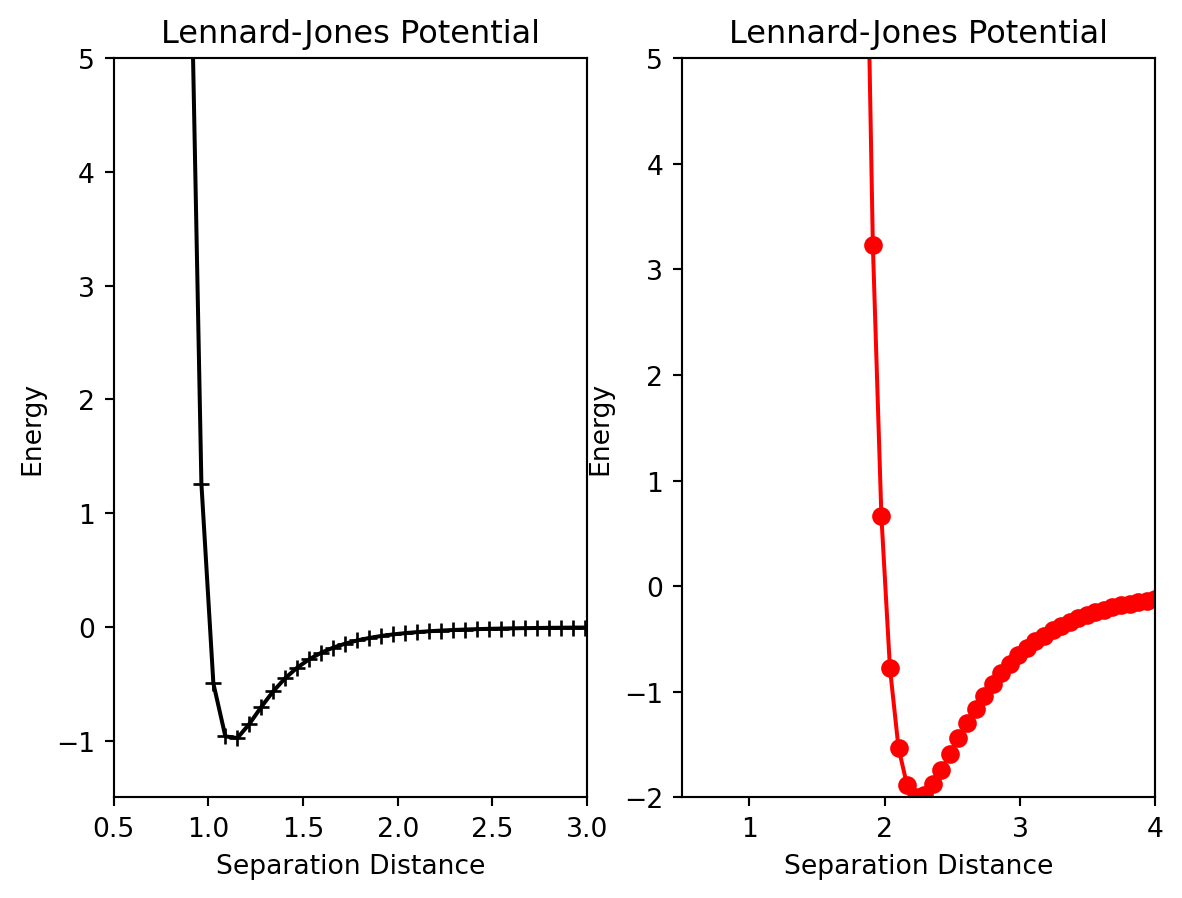

In [11]:
from matplotlib import pyplot as plt
%matplotlib inline
from numpy import linspace,sqrt

r = linspace(0.9,4,50)

sigmaOne = 1
epsilonOne = 1
sigmaTwo = 2
epsilonTwo = 2
energyOne = 4 * sigmaOne* ((epsilonOne/r)**12 - (epsilonOne/r)**6)
energyTwo = 4 * sigmaTwo * ((epsilonTwo/r)**12 - (epsilonTwo/r)**6)

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.plot(r,energyOne,marker = '+',color = 'k')
ax1.set_xlim(0.5,3.0)
ax1.set_ylim(-1.5,5)
ax1.set_xlabel("Separation Distance")
ax1.set_ylabel("Energy")
ax1.set_title("Lennard-Jones Potential")

ax2.plot(r,energyTwo,marker = 'o',color = 'r')
ax2.set_xlim(0.5,4.0)
ax2.set_ylim(-2,5)
ax2.set_xlabel("Separation Distance")
ax2.set_ylabel("Energy")
ax2.set_title("Lennard-Jones Potential")

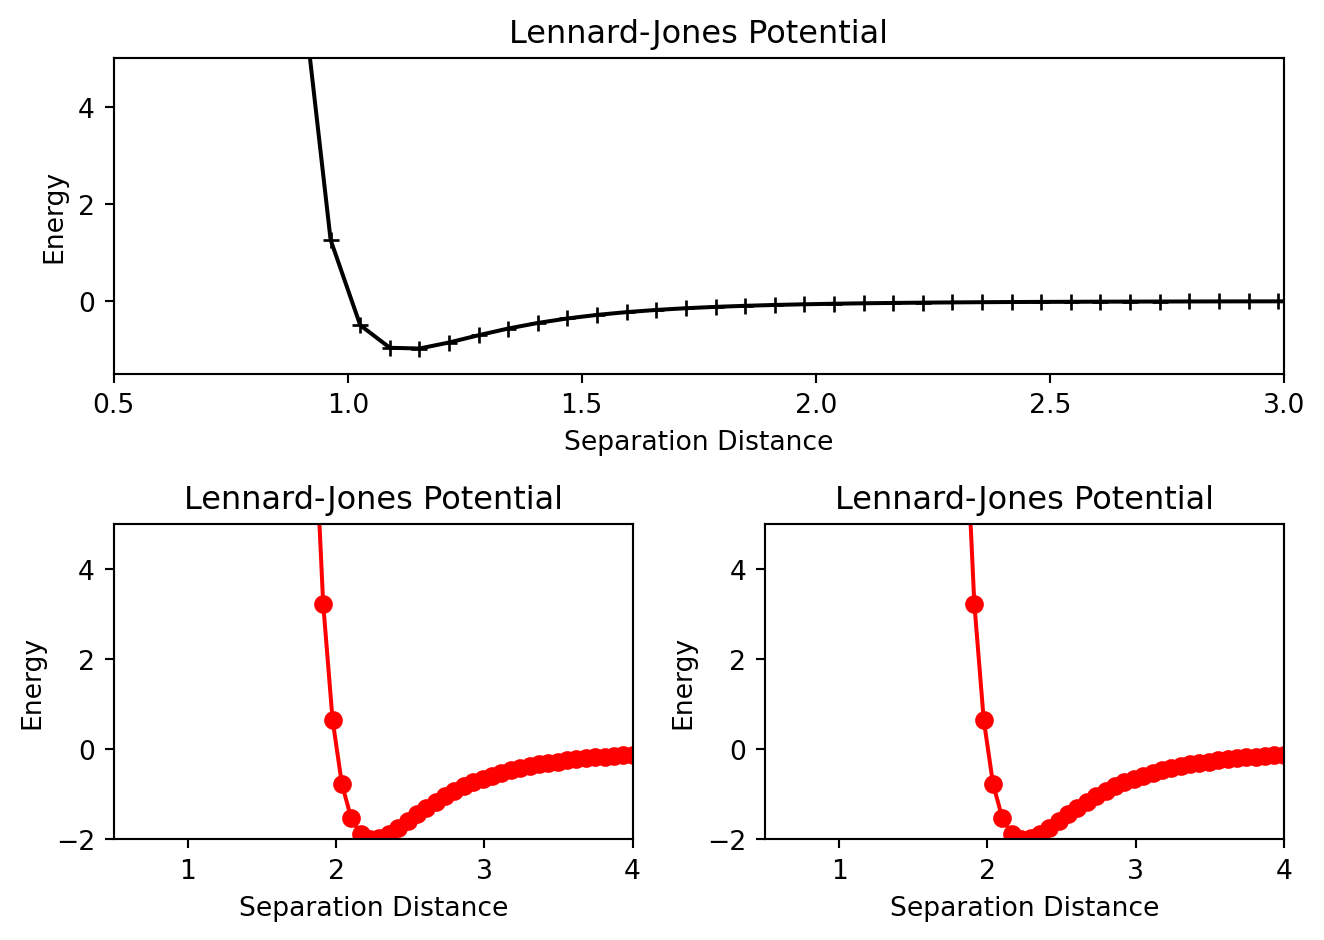

In [12]:
from matplotlib import pyplot as plt
%matplotlib inline
from numpy import linspace,sqrt

r = linspace(0.9,4,50)

sigmaOne = 1
epsilonOne = 1
sigmaTwo = 2
epsilonTwo = 2
energyOne = 4 * sigmaOne* ((epsilonOne/r)**12 - (epsilonOne/r)**6)
energyTwo = 4 * sigmaTwo * ((epsilonTwo/r)**12 - (epsilonTwo/r)**6)

fig = plt.figure()
ax1 = fig.add_subplot(2,1,1)
ax2= fig.add_subplot(2,2,3)
ax3 = fig.add_subplot(2,2,4)

ax1.plot(r,energyOne,marker = '+',color = 'k')
ax1.set_xlim(0.5,3.0)
ax1.set_ylim(-1.5,5)
ax1.set_xlabel("Separation Distance")
ax1.set_ylabel("Energy")
ax1.set_title("Lennard-Jones Potential")

ax2.plot(r,energyTwo,marker = 'o',color = 'r')
ax2.set_xlim(0.5,4.0)
ax2.set_ylim(-2,5)
ax2.set_xlabel("Separation Distance")
ax2.set_ylabel("Energy")
ax2.set_title("Lennard-Jones Potential")

ax3.plot(r,energyTwo,marker = 'o',color = 'r')
ax3.set_xlim(0.5,4.0)
ax3.set_ylim(-2,5)
ax3.set_xlabel("Separation Distance")
ax3.set_ylabel("Energy")
ax3.set_title("Lennard-Jones Potential")
plt.tight_layout()

In [13]:
#| echo: False
#| eval: True

import numpy as np
import pandas as pd
y = np.array([2,2.5,3,3.5,4])
g = 9.8
t = np.sqrt(2 * y /g)
df = pd.DataFrame(np.transpose([y,t]),columns = ["Initial height (meters)", "Fall time (seconds)"])
pd.set_option("display.precision",2)
display(df)

,Initial height (meters),Fall time (seconds)
0,2.0,0.64
1,2.5,0.71
2,3.0,0.78
3,3.5,0.85
4,4.0,0.90


In [14]:
import numpy as np

t = np.array([0.64,0.71,0.78,0.85,0.90])
y = np.array([2.0,2.5,3.0,3.5,4.0])

In [15]:
import numpy as np

t = np.array([0.64,0.71,0.78,0.85,0.90])
y = np.array([2.0,2.5,3.0,3.5,4.0])

g = 2 * y/t**2
print(g)

[9.765625   9.91866693 9.86193294 9.68858131 9.87654321]


In [16]:
#| eval: false
#| echo: true
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline



T =  
un_T = 
L =   
un_L = 
g =   
un_g =   
frac_un = 

df = # Creat a dataframe of your data. Give the columns appropriate names
display(df) # Display the dataframe

fig = plt.figure()            

plt.show()


In [17]:
#| eval: false
#| echo: true

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

trial = np.array([1,2,3,4,5,6,7,8,9,10])
fallDistances = 
un_distance = 
fallTimes = 
un_times = 
g = 
un_g = 
frac_g = 

df = # Creat a dataframe of your data. Give the columns appropriate names
display(df) # Display your dataframe


fig = plt.figure()            





plt.show()